This is the code of sequential Bayesian history matching (SBHM) algorithm for the three degree-of-freedom mass-spring system. The SBHM algorithm aims to generate posterior samples of model parameters as data arrives sequentially. 

In [1]:
# basic packages
import time
import numpy as np
import pandas as pd 
import functools as ft
import math as math
from scipy.stats import multivariate_normal
from scipy.stats import norm
from scipy.stats import qmc

# graphs
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.pyplot import figure
import seaborn as sns

# possible parallelisation
from multiprocess import Pool

# GP library
import GPy
from sklearn.model_selection import train_test_split
from scipy.spatial import distance_matrix


true = np.array([0.16,0.32,0.45])
me = 0.001
md = 0.001
# reproduction, initial observation:
obs = np.array([0.15984389, 0.31984049, 0.45238688]) 
# new obs in case 1: np.array([0.1579, 0.3178, 0.4500]) 
# new obs in case 2: np.array([0.1548, 0.3190, 0.4443]) 
# generate a random obs: true + np.random.randn(3)*me+np.random.randn(3)*md
print(obs)

# K matrix
def conK(x): # x:2-d since k1 and k6 are assumed to be unknown
    k = np.ones(6)
    k[0] = x[0]
    k[5] = x[1]
    K = [[k[0]+k[3]+k[5],-k[3],-k[5]],
        [-k[3], k[1]+k[3]+k[4],-k[4]],
        [-k[5],-k[4],k[2]+k[4]+k[5]]]
    return np.array(K)

# M(mass) matrix
M = np.diag(np.repeat(1,3))

# mass-spring model
def threeDOF(K):
    R = np.linalg.inv(M).dot(K)
    eigenval, eigenvec = np.linalg.eig(R)
    freq = np.round(sorted(np.sqrt(eigenval)/(2*math.pi)),4)
    return(freq)

# Implausibility measure
def Imp(obs,m,var):
    N = len(obs)
    return np.mean(np.abs(np.subtract(obs,m))/np.sqrt(np.repeat(md**2+me**2,N)+np.diag(var)))


[0.15984389 0.31984049 0.45238688]


In [3]:
# bounds for k1 and k6; make sure k1 k6 positive 
l_bounds = [0.05,0.05]
u_bounds = [10,10] 

### selection of the training data set for GP emulator
def maximin_subset_selection(points, subset_size):
    # Calculate the pairwise distance matrix
    dist_matrix = distance_matrix(points, points)
    
    subset_indices = [0]
    
    # Select points that maximize the minimum distance in the subset
    for _ in range(1, subset_size):
        # Calculate minimum distances from the subset to each point not yet selected
        min_distances = np.min(dist_matrix[subset_indices], axis=0)
        
        # Find the point with the maximum of these minimum distances
        next_index = np.argmax(min_distances)
        
        # Add the selected point to the subset
        subset_indices.append(next_index)
    
    return (points[subset_indices])

### GP emulator
def GP(X,Y):
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X = (X-X_mean)/X_std

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=42)
    
    
    inputs = X_train
    targets = Y_train
    y_mean = targets.mean(axis=0)
    y_std = targets.std(axis=0)
    targets = (targets-y_mean)/y_std
    
    # Reshape inputs and targets to have a single output per GP model
    models = []
    estimated_constant = []
    for i in range(3):  # 3-d output
        # Define the kernel for each GP model
        rbf = GPy.kern.RBF(input_dim=X_train.shape[1], variance=1., lengthscale=1.)
        rbf.lengthscale.constrain_bounded(1e-1, 10.0)
        kernel = rbf
        
        # Add a linear mean function to the GP model
        mean_function = GPy.mappings.Linear(X_train.shape[1], 1)
        
        # Create a GP model for each output dimension
        model = GPy.models.GPRegression(inputs, targets[:, i:i+1], kernel)
        model.optimize()
        print("Optimized length scale:", model.kern.lengthscale[0])

        #estimated_constant.append(model.kern.parts[0].variance[0])
        models.append(model)
    
 
    # Validation
    predict_points = X_test #.reshape(1,-1)
    preds = []
    y_vars = []
    for model in models:
        pred, var = model.predict(predict_points)
        preds.append(pred)
        y_vars.append(var)
        
    y_gp = np.transpose(np.array(preds)[:,:,0])*y_std + y_mean

    y_vars = np.transpose(np.array(y_vars)[:,:,0])*(y_std**2)
    
    sigma = 0
    for i in range(Y_test.shape[0]):
        y_cov = y_vars[i,:]
        sigma = sigma + np.mean(y_cov,axis = 0)
    sigma = np.sqrt(sigma/Y_test.shape[0])
    print('sigma:', sigma)
            
    return([sigma,y_std,y_mean,X_mean,X_std,models]) # return model

### GP emulator prediction
def prediction(y_std,y_mean,models, x_new):
    y_pre = []
    y_vars = []
    for model in models:
        pre, var = model.predict(x_new)
        y_pre.append(pre.flatten())
        y_vars.append(var.flatten())
    
    y_pre = (np.asarray(y_pre).reshape(3,))*y_std + y_mean
    y_vars =  ((np.asarray(y_vars)).reshape(3,))*(y_std**2)

    
    y_cov = np.diag(y_vars.flatten())

    return(y_pre,y_cov)

### modified metropolis algorithm
def modmetro(y_std,y_mean,X_mean, X_std,models,
             sd,ns,d,obs,seed,Y): # for each seed
    z = np.zeros((d,ns+1))
    z[:,0] = seed
    imp =  np.zeros(ns+1)
    mean, var = prediction(y_std,y_mean,models, ((seed-X_mean)/X_std).reshape(1, d))
    imp[0] = Imp(obs,mean,var)
    q = np.zeros(d)
    a = np.zeros(d)

    for m in range(ns):
        ### step 1 sampling
        a = z[:,m]+ multivariate_normal.rvs(mean=np.repeat(0,d), cov=np.diag(sd**2))
        rep_ind = np.where((l_bounds<a)&(a<u_bounds))
        q[:] = z[:,m]
        q[rep_ind] = a[rep_ind]
        
        ###step 2 determine whether q belongs to F_L or not
        q_rev = (q - X_mean)/X_std 
        mean, var = prediction(y_std,y_mean,models, q_rev.reshape(1, d)) ###store it
        imp_inter = Imp(obs,mean,var)
        if imp_inter < Y:
            z[:,m+1]=q
            imp[m+1] = imp_inter
        else:
            z[:,m+1]=z[:,m]
            imp[m+1] = imp[m]
        
    return([z,imp])

### make sure k1 k6 non-negative
def prior(x):
    between=True
    for i in range(len(x)):
        if not (u_bounds[i]>x[i] and l_bounds[i]<x[i]): 
            between=False
            break
    return(between)

### adaptive metropolis algorithm
def admetro(y_std,y_mean, X_mean, X_std,models,
    sd,d,obs,x,Y):
    res = x
    mean, var = prediction(y_std,y_mean,models, ((x-X_mean)/X_std).reshape(1, d))
    y = Imp(obs,mean,var)
    
    acc = 0
    zpot = x + multivariate_normal.rvs(mean=np.repeat(0,d), cov=np.diag(sd**2))
    mean, var = prediction(y_std,y_mean,models, ((zpot-X_mean)/X_std).reshape(1, d))
    y_z = Imp(obs,mean,var)
    
    if prior(zpot) and y_z < Y:
        alpha = multivariate_normal.pdf(zpot, mean=np.repeat(2,d), cov=np.diag(
        np.repeat(1,d))) / multivariate_normal.pdf(x, mean=np.repeat(2,d), cov=np.diag(
        np.repeat(1,d)))
        
        #norm.pdf(y_z) / norm.pdf(y)
        
        if np.random.uniform(0,1) <= alpha:
            res = zpot
            y = y_z
            acc = 1
    return([res,y,acc])

In [4]:
# Subset Simulation under the SMC framework

def sus(X, y_std,y_mean,X_mean,X_std, models, obs): #imp_list[im]
    #inner loop of SuS-based HM, i.e., subset simulation
    YF = 3 #critical threshold (gx>=YF)
    p = 0.1 #level probability
    n = X.shape[0] #number of samples
    d = X.shape[1] #dimension of samples
    nc = int(n*p) #number of Markov chains
    ns = int((1-p)/p) #number of states in each chain
    q = np.zeros(n) #probs
    
    L = 0
    Lmax = 100 # define the possible maximum of number of levels
    
    Xs = np.zeros((n,d,Lmax)) #samples for different levels
    nF = np.zeros(Lmax) # number of failure samples
    
    ys = np.zeros((Lmax,n)) # responses
    ys_or = np.zeros((Lmax,n)) # real responses
    
    Ys = np.zeros(Lmax)# intermediate threshold
    zs = np.zeros((nc,d, ns+1)) # seeds
    
    # Intialisation
    Xs[:,:,L] = X
    
    # Evaluation on emulators
    for i in range(n):
        x_rev = (Xs[i,:,L]-X_mean)/X_std
        mean,var = prediction(y_std,y_mean,models, x_rev.reshape(1, d))
        ys[L, i] = Imp(obs=obs,m=mean,var=var)
    
    nF[L] = len(np.where(ys[L,:]<YF)[0]) #samples falls in failure domain
    print('nFL=', nF[L])
    
    if __name__ == '__main__':
        with Pool(1) as pool: #possible parallelisations
            while (nF[L]/n)<1 and L<=5:
                L=L+1 # next conditional level is needed
                y_now = ys[L-1,:] 
                ind = sorted(range(len(y_now)), key=lambda k: y_now[k])# original index of increasing responses
                ys[L-1,:] = ys[L-1,ind] #renumbered responses
                Xs[:,:, L-1] = Xs[ind,:,L-1]
                Ys[L-1] = (ys[L-1,nc-1]+ys[L-1,nc])/2 #L^th intermediate threshold
                zs[:,:,0] = Xs[range(0,nc),:, L-1] # seeds of Markov chain
                print('L = ', L)
                print('intermediate threshold:',Ys[L-1])

                # step size used in sampling
                sd = 2.38* np.std(zs[:,:,0],axis = 0) # + np.repeat(1e-4,d) 
                print('std:', sd)
                
                # SMC structure
                ### resample
                q[:nc] = 1/nc
                q[nc:] = 0
                probs = q[:].tolist()
                
                ### adaptive metroplis, you can consider modified metropolis instead
                
                for j in range(nc, n):
                    thre = np.random.uniform(0, 1)
                    A = np.random.multinomial(1, probs)
                    A = A.tolist()
                    A = A.index(1)
                    Xs[j, :,L-1] = Xs[A,:,L-1]

                for s in range(1,6):
                    result = pool.map(lambda x: admetro(
                        y_std,y_mean, X_mean, X_std, models,
                        sd,d,obs,x,Ys[L-1]),
                            [Xs[i,:,L-1] for i in range(n)])
                    acc = 0
                    for j,i in enumerate(result):
                        Xs[j,:,L] = i[0]
                        ys[L,j] = i[1]
                        if i[-1] == 1:
                            acc = acc + 1
                    print(acc)
                    if acc/n<=0.3:
                        sd = np.sqrt(np.exp(np.log(sd**2) - np.repeat(np.log(d)/s,d)))
                    else:
                        sd = np.sqrt(np.exp(np.log(sd**2) + np.repeat(np.log(d)/s,d)))
                    print('std:', sd)                
                
                nF[L] = len(np.where(ys[L,:]<YF)[0])
                print('nFL=', nF[L])
            
    return(Xs[:,:,L])


In [5]:
### outer loop of HM
def HM(obs,n,d):
    YF = 3 # thershold for non-implausible domain
    p = 0.1 # level probability
    w = 0 # initial wave
    Wmax = 100 # maximum wave
    sigma = 500 # intial GP variances
    Xw = np.zeros((n,d,Wmax)) #samples for different waves
    nF_or = np.zeros(Wmax) # number of failure samples
    ys_or = np.zeros((Wmax,n)) # responses on the original simulator
    
    # evulate samples on the original simulator
    for i in range(n):
        Xw[i,:,w] = np.maximum(np.array(l_bounds),
                           multivariate_normal.rvs(mean=np.repeat(2,d), cov=np.diag(
        np.repeat(0.04,d))))
        ys_or[w,i] = Imp(obs,threeDOF(conK(Xw[i,:,w])),
                                  np.diag(np.repeat(0,len(obs))))
    nF_or[w] = len(np.where(ys_or[w,:]<YF)[0]) #samples falls in the original failure domain
    
    print('w = ', w)
    print('samples falls in failure domain:',nF_or[w])
    
    X_points = []
    Y_points = []
    
    while sigma >= me and nF_or[w]/n < p: 
        # Train GP emulator 
        if w < 1: 
            subset_size = 100
        else:
            subset_size = 25

        new_X_points = maximin_subset_selection(Xw[:,:,w], subset_size)
        X_points.extend(new_X_points)
        Y_points.extend(np.apply_along_axis(lambda x : 
                               threeDOF(conK(x)), 1, np.array(new_X_points))) #output
        
        sigma, y_std,y_mean, X_mean,X_std, models = GP(np.array(X_points),
                                                               np.array(Y_points))
        
        # increment wave w and update samples based on GP emulator
        w = w + 1

        Xw[:,:,w] = sus(Xw[:,:,w-1], y_std,y_mean,X_mean,X_std, models,obs)

        # evulate samples on the original simulator
        for i in range(n):
            ys_or[w,i] = Imp(obs,threeDOF(conK(Xw[i,:,w])),
                                      np.diag(np.repeat(0,len(obs))))
        nF_or[w] = len(np.where(ys_or[w,:]<YF)[0]) #samples falls in the original failure domain

        print('w = ', w)
        print('samples falls in failure domain:',nF_or[w])
                    
    return(Xw[:,:,:(w+1)])

In [7]:
# History Matching

N = 1000
obs = obs
start_time = time.time()
X=HM(obs,N,2) # samples generated from HM for a static observation
print("--- %s seconds ---" % (time.time() - start_time))
y = np.zeros(X.shape[0])
for i in range(X.shape[0]):
    y[i] = Imp(obs,threeDOF(conK(X[i,:,-1])),np.diag(np.repeat(0,3)))
print('min of y=',min(y))



reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale


w =  0
samples falls in failure domain: 0.0
Optimized length scale: 9.999964464295086
Optimized length scale: 5.470817500108917
Optimized length scale: 9.99998840876476
sigma: 2.9609725130323256e-05
nFL= 0.0
L =  1
intermediate threshold: 12.766044610375737
std: [0.50663215 0.19652919]
557
std: [0.71648606 0.27793425]
425
std: [0.85205032 0.33052139]
392
std: [0.95639414 0.37099772]
353
std: [1.04295521 0.40457588]
335
std: [1.11781171 0.43361369]
nFL= 5.0
L =  2
intermediate threshold: 8.735384666470644
std: [1.01151622 0.40557412]
271
std: [0.71524998 0.28678421]
378
std: [0.85058036 0.34104582]
328
std: [0.95474417 0.382811  ]
280
std: [0.87550427 0.35103923]
302
std: [0.93834224 0.37623453]
nFL= 60.0
L =  3
intermediate threshold: 3.923666825507
std: [0.53776351 0.31476178]
226
std: [0.38025623 0.22257019]
358
std: [0.45220341 0.26468206]
300
std: [0.40286744 0.2358049 ]
296
std: [0.36943107 0.21623405]
378
std: [0.39594642 0.23175392]
nFL= 554.0
L =  4
intermediate threshold: 1.46

In [8]:
# HM results

estimation = np.mean(X[:,:,-1],axis = 0)
print(estimation) # mean of non-implausible samples; estimation of unknown parameters
print(np.std(X[:,:,-1],axis = 0)) # variance of non-implausible samples
print(threeDOF(conK(estimation))) # output with the estimated parameters
# df = pd.DataFrame(X[:,:,-1]) # store data
# df.to_csv('3DOF_HM_new_final.csv')

[0.98879963 3.04856635]
[0.08610872 0.0615348 ]
[0.1589 0.3182 0.4527]


In [11]:
# Initialisation of SBHM

### metropolis algorithm
def accept(x,
           y_std,y_mean, X_mean,X_std, models,
           d,sigma,temp,obs):
    res = x
    x_rev = (x-X_mean)/X_std
    mean, var = prediction(y_std,y_mean,models, x_rev.reshape(1, d))
    inner = norm.pdf(Imp(obs,mean,var))
    acc = 0
    zpot = x+multivariate_normal.rvs(mean=np.repeat(0,d), cov=np.diag(sigma))
    if prior(zpot):
        z_rev = (zpot-X_mean)/X_std
        mean, var = prediction(y_std,y_mean, models, z_rev.reshape(1, d))
        inner_z = norm.pdf(Imp(obs,mean,var))
        alpha = inner_z
        alpha = (alpha / inner)**(temp)
        if np.random.uniform(0,1) <= alpha:
            res = zpot
            inner = inner_z
            acc = 1
    return([res,inner,acc])

### bisection method
def bise(inner, ESS, lower, upper, Nthre, thre):
    a = lower
    b = upper
    while abs(ESS-Nthre)>thre:
        mid = (a+b)/2
        weights = inner**(mid-lower)
        w_sum = sum(weights)

        if w_sum!= 0:
            weights = weights / w_sum
            ESS = 1 / sum(weights**2)
        else:
            ESS= 0

        if ESS<Nthre:
            b = mid
        else:
            a = mid
    temp = mid
    return(temp)

### SMC after HM(SuS) to generate posterior samples for a static observation
def smcsus(obs,X):
    d = X.shape[1] #dimension of the input space 
    n = X.shape[0]
    L = 0 # zero level
    Nthre = 0.75*n # ESS threshold
    thre = 1 # stopping rule for bisection
    Lmax = 100 # define the possible maximum of number of levels
    Xs = np.zeros((n,d,Lmax)) #samples for different levels
    phi= np.zeros(Lmax)
    
    # generate initial samples based on non-implausible samples from HM
    mean = np.mean(X,axis = 0)
    std = np.std(X,axis = 0) + np.repeat(1e-4,d)
    
    sampler = qmc.LatinHypercube(d=d)
    sample = sampler.random(n=n)
    
    xs = qmc.scale(sample, np.maximum(mean-3*std,l_bounds),np.minimum(mean+3*std,u_bounds))

    Xs[:,:,0] = xs ### samples for zero level
    zs = np.zeros((n,d))### resampling
    inner = np.zeros(n)
    
    q = np.zeros((Lmax,n))  ### normalised weight
    sigma = 2.38*np.diag(np.cov(np.transpose(xs)))
       
    if __name__ == '__main__':
        with Pool(1) as pool:
            ### retrain a GP here (Perhaps no needs)
            subset_size = 100
            X_points = maximin_subset_selection(Xs[:,:,L], subset_size)
            Y_points = np.apply_along_axis(lambda x : 
                                    threeDOF(conK(x)), 1, X_points)
            si, y_std,y_mean, X_mean,X_std, models = GP(X_points,
                                                                   Y_points)
            
            while phi[L]<1: # stopping criterion
                ### log likelihood ratio
                for i in range(n):
                    x_rev = (Xs[i,:,L]-X_mean)/X_std
                    mean, var = prediction(y_std,y_mean, models, x_rev.reshape(1, d))
                    inner[i] = norm.pdf(Imp(obs,mean,var))   

                ### specify the next tempering hyperparameter phi[L+1]
                q[L+1,:]  = inner**(1-phi[L])           
                if sum(q[L+1,:])!= 0:
                    q[L+1,:]=q[L+1,:]/sum(q[L+1,:])
                    ESS = 1/sum(q[L+1,:]**2)
                else:
                    ESS= 0
                    
                ## iterative bisection method to solve ESS approx N_thresh = alpha* N (the rate is not fixed here)
                if ESS > Nthre:
                    phi[L+1] = 1 
                else:
                    phi[L+1] = bise(inner,ESS,phi[L],1, Nthre, thre)
                print('Threshold =',phi[L+1])
                
                ### increment L
                L += 1
                Xs[:,:,L] = Xs[:,:,L-1]
                
                ### reweight
                probs = q[L,:].tolist()
                
                ### resample
                zs[:,:] =  Xs[:,:,L] 
                for j in range(1, n + 1):
                    thre = np.random.uniform(0, 1)
                    bb = q[L, j - 1]/max(q[L,:])
                    if thre >= bb:
                        A = np.random.multinomial(1, probs)
                        A = A.tolist()
                        A = A.index(1)
                        Xs[j-1, :,L] = zs[A, :]
                
                ### MCMC move
                for s in range(1,6):
                    result = pool.map(lambda x: accept(x,
                            y_std,y_mean, X_mean,X_std, models,
                            d,sigma,phi[L],obs),
                            [Xs[i,:,L] for i in range(n)])
                    acc = 0
                    for j,i in enumerate(result):
                        Xs[j,:,L] = i[0]
                        inner[j] = i[1]
                        if i[-1] == 1:
                            acc = acc + 1
                    print(acc)
                    if acc/n<=0.3:
                        sigma = np.exp(np.log(sigma) - np.repeat(np.log(d)/s,d))
                    else:
                        sigma = np.exp(np.log(sigma) + np.repeat(np.log(d)/s,d))
                    print(sigma)
                    
                # retrain GP
                subset_size = 100
                X_points = maximin_subset_selection(Xs[:,:,L], subset_size)
                Y_points = np.apply_along_axis(lambda x : 
                                        threeDOF(conK(x)), 1, X_points)
                si, y_std,y_mean, X_mean,X_std, models = GP(X_points,
                                                                       Y_points)

                
    return(Xs[:,:,:(L+1)])

In [12]:

start_time = time.time()
NewX = smcsus(obs,X[:,:,-1])
print("--- %s seconds ---" % (time.time() - start_time))


reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale


Optimized length scale: 9.999978995316187
Optimized length scale: 9.999819464367375
Optimized length scale: 9.999982192333897
sigma: 3.161881257633649e-05
Threshold = 0.302734375
367
[0.1062277  0.05430442]
261
[0.07511433 0.03839902]
337
[0.09463812 0.04837973]
298
[0.07958086 0.04068235]


reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale


306
[0.0914144  0.04673174]
Optimized length scale: 9.99999656819998
Optimized length scale: 9.999999622785689
Optimized length scale: 9.99999927866226
sigma: 3.214880801199229e-05
Threshold = 0.6976699829101562
145
[0.0457072  0.02336587]
267
[0.03231987 0.01652217]
328
[0.04072049 0.02081663]
298
[0.03424171 0.01750463]


reconstraining parameters rbf.lengthscale


326
[0.0393334  0.02010753]


reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale


Optimized length scale: 9.999999529468257
Optimized length scale: 9.999999628868766
Optimized length scale: 9.999990646567529
sigma: 2.8580509162495376e-05
Threshold = 1.0
254
[0.0196667  0.01005377]
367
[0.02781291 0.01421817]
301
[0.03504207 0.01791378]
287
[0.02946675 0.01506363]


reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale


283
[0.0256523  0.01311365]
Optimized length scale: 9.99999950673838
Optimized length scale: 9.999989997558295
Optimized length scale: 9.99999434174407
sigma: 2.978797128675744e-05
--- 21.677225351333618 seconds ---


[1.0646463  3.02462916]


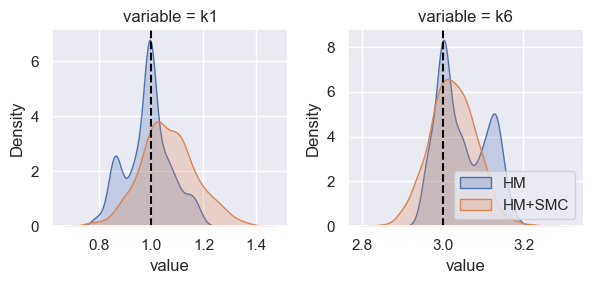

In [13]:
print(np.mean(NewX[:,:,-1], axis = 0)) # mean of posterior samples

# Comparison of non-implausible and posterior samples with true values
columns = ['k1','k6']
c1 = pd.DataFrame(X[:,:,-1], columns = columns)
c1.insert(0,'Algorithm','HM')
c2 = pd.DataFrame(NewX[:,:,-1], columns = columns)
c2.insert(0,'Algorithm','HM+SMC')
Data = pd.concat([c1,c2])
Data2 = pd.melt(Data, Data.columns[0], Data.columns[1:])

sns.set()
g = sns.FacetGrid(Data2, col="variable", hue="Algorithm",col_wrap=4,sharex=False,sharey=False)
g.map(sns.kdeplot, "value", fill=True)
true_values = [1,3]

for idx, ax in enumerate(g.axes.flat):
    true_val = true_values[idx]
    ax.axvline(true_val, color='black', linestyle='--', linewidth=1.5)

plt.legend(loc = 'lower right')
plt.show()

In [14]:
estimation = np.mean(NewX[:,:,-1],axis = 0) # mean of posterior samples; estimation of unknown parameters
print(estimation)
print(np.std(NewX[:,:,-1],axis = 0)) # variance of posterior samples
print(threeDOF(conK(estimation))) # output with the updated estiamted paramaters
# df = pd.DataFrame(NewX[:,:,-1]) # store data
# df.to_csv('3DOF_HMSMC_case2.csv')

[1.0646463  3.02462916]
[0.10768216 0.05937426]
[0.1608 0.3187 0.4525]


In [24]:
# Main procedure of SBHM

### Metropolis
def accept_seq(x,
    y_std,y_mean, X_mean,X_std, models,
    d,sigma,obs_new,obs,temp):
    
    res = x
    
    x_rev = (res-X_mean)/X_std
    mean, var = prediction(y_std,y_mean, models, x_rev.reshape(1, d))
    inner_new = norm.pdf(Imp(obs_new,mean,var))  
    inner_old = norm.pdf(Imp(obs,mean,var))  

    inner = inner_new / inner_old
    
    acc = 0
    alpha = 0
    
    zpot = x + multivariate_normal.rvs(mean=np.repeat(0,d), cov=np.diag(sigma))
    zpot_rev = (zpot - X_mean)/X_std
     
    if prior(zpot):
        meanz, varz = prediction(y_std,y_mean,
                         models, zpot_rev.reshape(1, d))
        innerz_new = norm.pdf(Imp(obs_new,meanz,varz))
        innerz_old = norm.pdf(Imp(obs,meanz,varz))
        inner_z = innerz_new / innerz_old

        alpha = (innerz_new**(temp))*(innerz_old**(1-temp))
        alpha = alpha/((inner_new**(temp))*(inner_old**(1-temp)))

        if np.random.uniform(0,1) <= alpha:
            res = zpot
            inner = inner_z
            acc = 1
        
    return([res,inner,acc])

# the main sequential Monte Carlo sampler
def smc(obs,obs_new,X_smc):
    start_time = time.time()
    n=X_smc.shape[0]
    d=X_smc.shape[1]
    L = 0 # zero level
    Nthre = 0.85*n # ESS threshold
    thre = 1 # stopping rule for bisection
    Lmax = 100 # define the possible maximum of number of levels
    Xs = np.zeros((n,d,Lmax)) #samples for different iterations
    phi= np.zeros(Lmax)
    
    inner = np.zeros(n) ### update weights
    thre_inner = np.zeros(n) ### update weights for stopping rule
    
    Xs[:,:,0] = X_smc[:,:] ### samples for zero level
    zs = np.zeros((n,d))### resampling
    inner = np.zeros(n)
    q = np.zeros((Lmax,n))  ### normalised weight
    sigma = 2.38*np.diag(np.cov(np.transpose(X_smc))) ### variance in metropolis
    boo = True
    
    if __name__ == '__main__':
        with Pool(1) as pool:
            ### retrain a GP
            subset_size = 100
            X_points = maximin_subset_selection(Xs[:,:,L], subset_size)
            Y_points = np.apply_along_axis(lambda x : 
                                    threeDOF(conK(x)), 1, X_points)
            Y_points_new = np.apply_along_axis(lambda x : 
                                    threeDOF(conK(x)), 1, X_points)
            
            si, y_std,y_mean, X_mean,X_std, models = GP(X_points, Y_points)

            ### ESS computation
            for i in range(n):
                x_rev = (Xs[i,:,L]-X_mean) / X_std
                mean, var = prediction(y_std,y_mean,
                         models, x_rev.reshape(1, d))
                thre_inner[i] = Imp(obs_new,mean,var)
                
            if sum(thre_inner)!= 0:
                thre_inner=thre_inner/sum(thre_inner)
                ESS = 1/sum(thre_inner**2)
            else:
                ESS = 0
            print('ESS = ', ESS)
            
            if ESS <= 0.7*n:
                boo = False # ESS too low, no need to use previous information
            else:
                while phi[L]<1: # stopping criterion
                    
                    ### log likelihood ratio
                    for i in range(n):                    
                        x_rev = (Xs[i,:,L]-X_mean) / X_std
                        mean, var = prediction(y_std,y_mean,
                         models, x_rev.reshape(1, d))

                        inner[i] = Imp(obs_new,mean,var)/Imp(obs,mean,var)
                    
                    ## ESS and temperature hyperparameter updates
                    q[L+1,:] = inner ** (1-phi[L])

                    if sum(q[L+1,:])!= 0:
                        q[L+1,:]=q[L+1,:]/sum(q[L+1,:])
                        ESS = 1/sum(q[L+1,:]**2)
                    else:
                        ESS= 0

                    q[L+1,:]=q[L+1,:]/np.sum(q[L+1,:])
                    ESS = 1/np.sum(q[L+1,:]**2)

                    if  ESS > Nthre:
                        phi[L+1] = 1
                        
                    else:
                        q[L+1,:] = inner ** (phi[L]-phi[L-1])
                        q[L+1,:]=q[L+1,:]/np.sum(q[L+1,:])
                        ESS = 1/np.sum(q[L+1,:]**2)
                        
                        if L > 0:
                            if ESS > 0.5*n and ESS < 0.9*n:
                                phi[L+1] = 2*phi[L]-phi[L-1]
                            else:
                                if ESS >= 0.9*n:
                                    phi[L+1] = bise(inner,ESS,2*phi[L]-phi[L-1],1, Nthre, thre)
                                else:
                                    phi[L+1] = bise(inner,ESS,phi[L],2*phi[L]-phi[L-1], Nthre, thre)
                        else: 
                            phi[L+1] = bise(inner,ESS,phi[L],1, Nthre, thre)
                    print('Temperature =', phi[L+1])
                

                    L += 1 ### increment
                    Xs[:,:,L] = Xs[:,:,L-1]
                    
                    ### reweight
                    probs = q[L,:].tolist()
                    
                    ### resample
                    zs[:,:] =  Xs[:,:,L] 
                    for j in range(1, n + 1):
                        thre = np.random.uniform(0, 1)
                        bb = q[L, j - 1]/max(q[L,:])
                        if thre >= bb:
                            A = np.random.multinomial(1, probs)
                            A = A.tolist()
                            A = A.index(1)
                            Xs[j-1, :,L] = zs[A, :]
                            
                    ### MCMC move
                    for s in range(1,6):
                        result = pool.map(lambda x: accept_seq(x,
                    y_std,y_mean, X_mean,X_std, models,
                                d,sigma,obs_new,obs,temp = phi[L]),
                                    [Xs[i,:,L] for i in range(n)])
                        acc = 0
                        for j,i in enumerate(result):
                            Xs[j,:,L] = i[0]
                            inner[j] = i[1]
                            if i[-1] == 1:
                                acc = acc + 1
                        print( acc)
                        if acc/n<=0.3:
                            sigma = np.exp(np.log(sigma) - np.repeat(np.log(d)/s,d))
                        else:
                            sigma = np.exp(np.log(sigma) + np.repeat(np.log(d)/s,d))
                        print(sigma)
                    
                    # retrain GP
                    subset_size = 100
                    X_points = maximin_subset_selection(Xs[:,:,L], subset_size)
                    Y_points = np.apply_along_axis(lambda x : 
                                            threeDOF(conK(x)), 1, X_points)

                    si, y_std,y_mean, X_mean,X_std, models= GP(X_points,Y_points)
                    
        print("--- %s seconds ---" % (time.time() - start_time))
    return([Xs[:,:,:(L+1)],boo])

In [27]:
# true_new = np.array([0.95,3.0])
# print(true_new)
# true_inv = threeDOF(conK(true_new))
# print(true_inv)

obs_new =  np.array([0.1548, 0.3190, 0.4443]) # hard new obs
# simple new obs: np.array([0.1579, 0.3178, 0.4500]) 
# print(obs_new)

# obs = np.array([0.15984389, 0.31984049, 0.45238688])
# print(obs)

UpdateX, boo = smc(obs,obs_new,NewX[:,:,-1])

reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale


Optimized length scale: 9.99999950673838
Optimized length scale: 9.999989997558295
Optimized length scale: 9.99999434174407
sigma: 2.978797128675744e-05
ESS =  935.4695897306304
Temperature = 0.8984375
510
[0.05524958 0.01679724]
370
[0.0781347  0.02375488]
292
[0.06201555 0.01885426]
305
[0.07374934 0.02242162]


reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale


264
[0.06420253 0.01951915]
Optimized length scale: 9.99999508185862
Optimized length scale: 9.999995644526745
Optimized length scale: 9.999880496930443
sigma: 3.316750770750069e-05
Temperature = 1.0
291
[0.03210126 0.00975958]
344
[0.04539804 0.01380213]
290
[0.03603245 0.01095475]
327
[0.04285005 0.01302747]


reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.lengthscale


300
[0.03730313 0.01134107]
Optimized length scale: 9.999970988479156
Optimized length scale: 9.999993349973648
Optimized length scale: 9.99976938320409
sigma: 3.265238296711487e-05
--- 14.531316041946411 seconds ---


In [28]:
estimation = np.mean(UpdateX[:,:,-1],axis = 0) # mean of posterior samples for the second obs
# print(true_inv)
# print(obs_new)
print(estimation)
print(np.std(UpdateX[:,:,-1],axis = 0)) # variance
print(threeDOF(conK(estimation))) # output with updated parameters for the new obs
# df = pd.DataFrame(UpdateX[:,:,-1]) # store data
# df.to_csv('3DOF_SBHM_lowerA_case2.csv')

[0.90267404 2.93172993]
[0.13071315 0.07431997]
[0.1565 0.3177 0.4449]
